# imports

In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/Users/andreassteiner/git/rizhom/env/bin/python


In [2]:
from matplotlib import pyplot as plt
import numpy as np
import numpy
import scipy.io.wavfile
import scipy.signal

import pyaudio
import aubio
# import bob.ap

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
    import os.path, sys

    lib_path = '../py'
    assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
    if not lib_path in sys.path:
        sys.path.insert(0, lib_path)

    import abase, audio, features, settings, streaming, util

In [5]:
# Using interface `0` by default.
p = pyaudio.PyAudio()
for i in range(p.get_device_count()):#list all available audio devices
    dev = p.get_device_info_by_index(i)
    print((i, dev['name'], dev['maxInputChannels']))

(0, 'Built-in Microphone', 2)
(1, 'Built-in Output', 0)
(2, 'iShowU Audio Capture', 2)
(3, 'Multi-Output Device', 0)


# record

In [8]:
settings.to_string()

'rate=16000 buf_secs=0.064s (1024) hop_secs=0.032s (512) '

* recording
* done recording


(111616, 6.976)

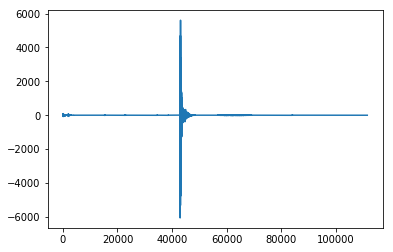

In [11]:
# record ...
data = audio.record(secs=7)
plt.plot(data)
len(data), len(data)/settings.rate

In [94]:
# store recording...
scipy.io.wavfile.write('../recordings/t_a_5.wav', rate, data)
# !ls -lh ../recordings/*

-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 21:46 ../recordings/a_welle.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_3.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:12 ../recordings/m_g_4.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:12 ../recordings/m_g_5.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_3.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_4.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:14 ../recordings/o_a_5.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:56 ../recordings/o_g_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:57 ../recordings/o_g_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:57 ../recordings/o_g_3.wav
-rw-

In [7]:
ab = abase.ABase(load_wav=True)
ab

ABase(n=35, series=8, what=o:15|t:14|m:5|w:1, who=g:15|a:11|p:9)

In [12]:
ab.play('o_g_1', stop=2)

# abase, transform

In [295]:
ab = abase.ABase(load_wav=True)

Updated 36/36 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/logmel.pickle : 3.74M (0.0s)


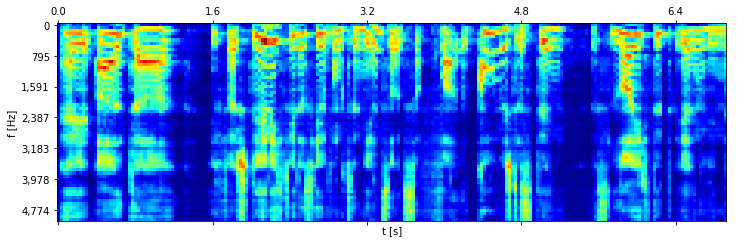

In [296]:
ab.transform('logmel', lambda row: features.log_mel_spectrogram(row['wav']))
util.plot_logmel(ab.df.loc[ab.sample(), 'logmel'])

loaded 36/36 (100.00%)
Updated 36/36 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/mfccs.pickle : 0.70M (0.0s)


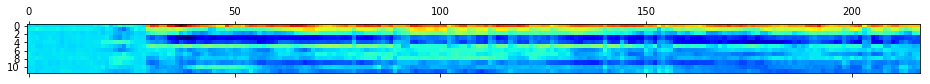

In [297]:
ab.load('logmel')
ab.transform('mfccs', lambda row: features.mfccs(data=None, logmel=row['logmel']))
plt.matshow(ab.df.loc[ab.sample(), 'mfccs'].T, cmap='jet')

# analyze

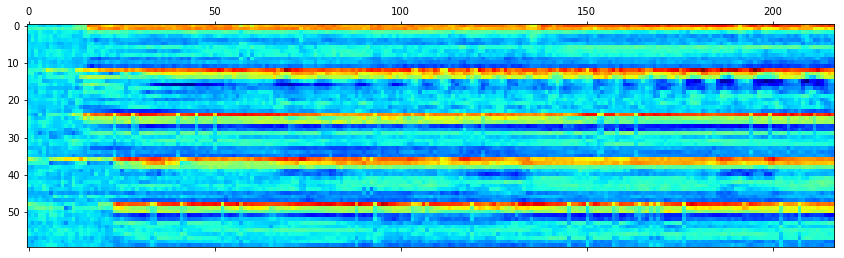

In [292]:
plt.matshow(np.hstack(ab.df.loc[ab.query('what == "o"').sample(5)].mfccs.values).T, cmap='jet')

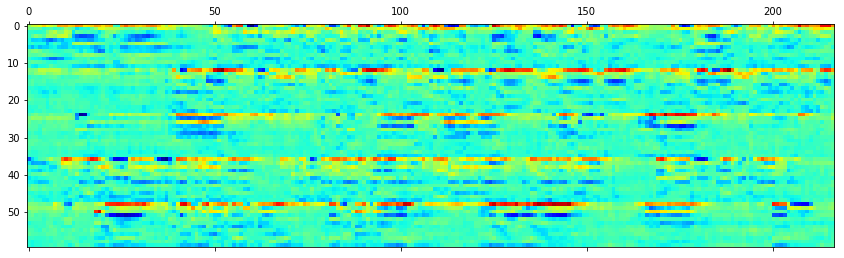

In [293]:
plt.matshow(np.hstack(ab.df.loc[ab.query('what == "t"').sample(5)].mfccs.values).T, cmap='jet')

## streaming implementation

In [71]:
streaming.OutlierFilter(d=10, n=1)([100, 100, 101, 102, 0, 105])

array([  0, 100, 101, 102, 102, 102])

In [72]:
streaming.MovingAverage(n=2)([0, 1, 2, 2])

array([0. , 0.5, 1. , 1. ])

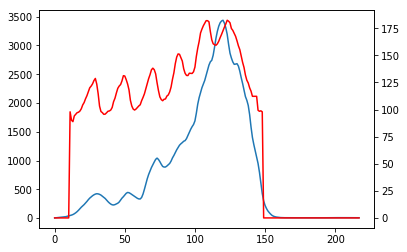

In [111]:
class Pitcher:
    def __init__(self, tolerance=0.8):
        self.pitcher = aubio.pitch(
            method='yinfft', buf_size=settings.buf_size,
            hop_size=settings.hop_size, samplerate=settings.rate)
        self.pitcher.set_unit('Hz')
        self.pitcher.set_tolerance(tolerance)
        self.outlier_filter = streaming.OutlierFilter(d=100, n=2)

    def __call__(self, data):
        pitch = self.pitcher(util.int16_to_float(data[:settings.hop_size]))
        assert len(pitch) == 1
        return self.outlier_filter(pitch[0])


class Louder:
    def __init__(self):
        self.envelop_averager = streaming.EnvelopAverager(
            buf_size=settings.buf_size, n=10)

    def __call__(self, data):
        return self.envelop_averager(data)

pitcher = Pitcher()
louder = Louder()
pitches = []
louds = []
for buf in util.Streamer(ab.wav('w_a_1')):
    pitches.append(pitcher(util.int16_to_float(buf)))
    louds.append(louder(buf))

plt.plot(louds)
plt.twinx()
plt.plot(pitches, 'r');

In [ ]:
df.sample()

Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/loud.pickle : 0.06M (0.0s)
Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/pitch.pickle : 0.03M (0.0s)
o => b
t => g
m => r


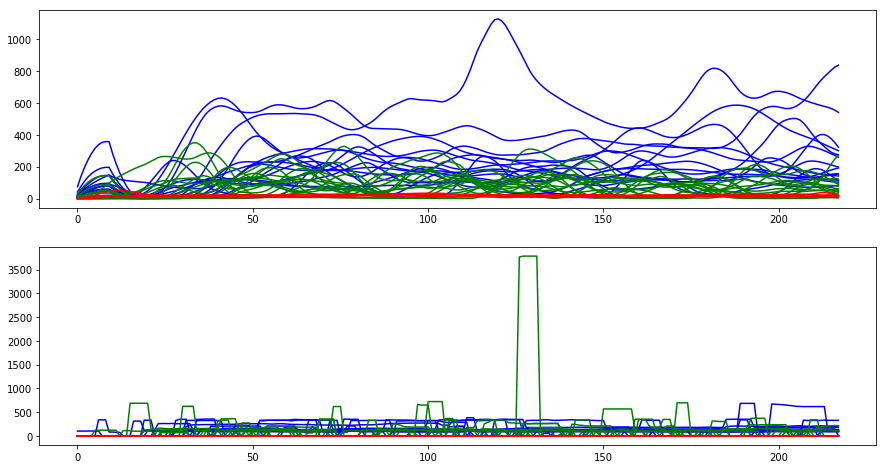

In [116]:

def plot_loud_pitch(ab, whats, tolerance=0.8, sample=0):

    def make_loud(row):
        louder = Louder()
        return np.array([
            louder(envelop_averager(buf))
            for buf in util.Streamer(row['wav'])
        ])

    def make_pitch(row):
        pitcher = Pitcher(tolerance=tolerance)
        return np.array([
            pitcher(buf)
            for buf in util.Streamer(row['wav'])
        ])

    ab.clear('loud')
    ab.transform('loud', make_loud)

    ab.clear('pitch')
    ab.transform('pitch', make_pitch)

    cols = ('b', 'g', 'r', 'k')
    _, axs = plt.subplots(2, 1, figsize=(15, 8))
    for i, what in enumerate(whats):
        col = cols[i % len(cols)]
        print('{} => {}'.format(what, col))
        df = ab.df.query('what == "{}"'.format(what))
        if sample:
            df = df.sample(n=sample)
            
        axs[0].plot(np.array(list(df.loud)).T, col)
        axs[1].plot(np.array(list(df.pitch)).T, col)

plot_loud_pitch(ab, whats=('o', 't', 'm'))

Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/loud.pickle : 0.06M (0.0s)
Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/pitch.pickle : 0.03M (0.0s)
o => b
t => g
m => r


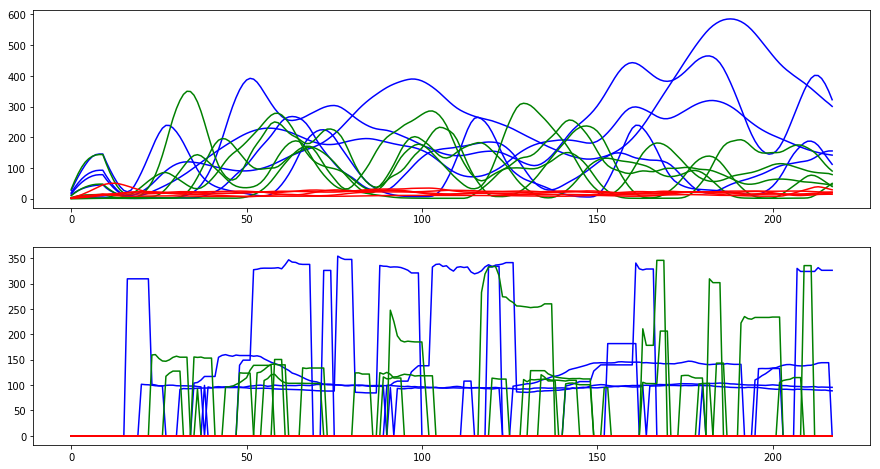

In [121]:
plot_loud_pitch(ab, whats=('o', 't', 'm'), tolerance=0.3, sample=5)

## original implementation

(64, 217)


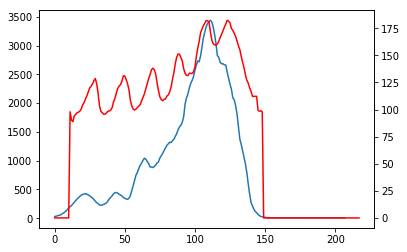

In [16]:
def moving_average(a, n=3) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

def binned_average(data, n):
    w = data.shape[0] // n
    data = data[:n*w]
    data = np.reshape(data, (n, w))
    return np.mean(data, axis=1)

def get_pitch(data, method='yinfft', tolerance=0.8):
    data_float = (data / 2**15).astype(np.float32)
    pitch_detector = aubio.pitch(method=method, buf_size=buf_size, hop_size=hop_size, samplerate=rate)
    pitch_detector.set_unit('Hz')
    pitch_detector.set_tolerance(tolerance)
    return [
        pitch_detector(data_float[i*hop_size:(i+1)*hop_size])[0]
        for i in range(data.shape[0]//hop_size)
    ]

def filter_outliers(vs, d=100, n=2):
    return list(OutlierFilter(d=d, n=n)(vs))

x = logmel.T
print(x.shape)
plt.plot()
# loudness in blue
plt.plot(moving_average(binned_average(np.abs(data), n=x.shape[1]), n=10))
plt.gca().twinx()
# pitch in red
plt.plot(filter_outliers(get_pitch(data)), 'r')

[]

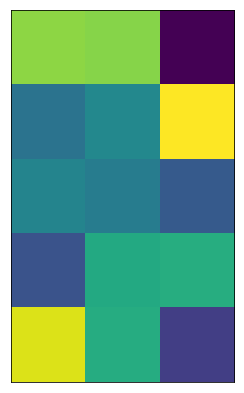

In [27]:
x = np.random.normal(size=(5, 3))
t = plt.matshow(x)
a = plt.gca()
a.set_xticks([])
a.set_yticks([])

In [32]:
import glob, os

os.listdir('.')
glob.glob('{}/*.wav'.format(os.path.dirname(__file__)))

[]

In [21]:
t()

# effects

'o_p_3'

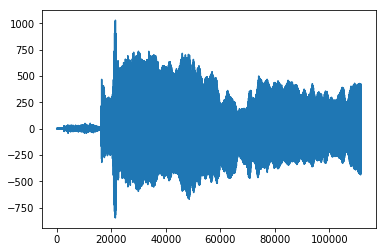

In [132]:
name = ab.sample()
wav = ab.df.loc[name].wav
plt.plot(wav)
name

## echo

In [273]:
class EchoDelayEffect:
    def __init__(self, delay_s=0.2, coeff=0.7):
        """Use coeff=0 for pure delay."""
        self.delay_s = delay_s
        self.delay_n = int(delay_s / settings.hop_secs)
        self.coeff = coeff
        self.bufs = np.zeros((self.delay_n, settings.hop_size))
        self.i = 0

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[:settings.hop_size]
        n = self.bufs.shape[0]
        delayed = self.bufs[self.i % n].copy()
        if self.coeff > 0:
            self.bufs[self.i % n] = buf + delayed * self.coeff
            ret = self.bufs[self.i % n]
        else:
            self.bufs[self.i % n] = buf
            ret = delayed
        self.i += 1
        return ret


# does NOT work (need clicking)
class LowpassEffect:
    def __init__(self, cutoff=880, numtaps=40):
        self.h = scipy.signal.firwin(numtaps=numtaps, cutoff=cutoff,
                                     nyq=settings.rate/2)

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = scipy.signal.lfilter(self.h, 1.0, buf)
        d = int((settings.buf_size - settings.hop_size)/2)
        return buf[d: settings.hop_size]

audio_interface = audio.AudioInterface(output_channels = 1)
effect = EchoDelayEffect()
# effect = EchoDelayEffect(delay_s=2, coeff=0)
# effect = LowpassEffect()
secs = 0
wav = ab.df.loc['o_p_2', 'wav']
for i, data in enumerate(util.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## stereo

In [276]:
class PanSinusEffect:
    def __init__(self, period_s=4):
        self.period_s = period_s
        self.i = 0

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[: settings.hop_size]
        v = (1 + np.sin(self.i * settings.hop_secs / self.period_s * 2 * np.pi)) / 2
        self.i += 1
        left = buf * v
        right = buf * (1 - v)
        return np.vstack([left, right]).reshape(-1, order='F')

class RightDelayEffect:
    def __init__(self, delay_s=2):
        self.delay_s = delay_s
        self.delay_effect = EchoDelayEffect(delay_s=delay_s, coeff=0)

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        left = buf[: settings.hop_size]
        right = self.delay_effect(buf)
        return np.vstack([left, right]).reshape(-1, order='F')

class MonoToStereoEffect:
    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[: settings.hop_size]
        return np.vstack([buf, buf]).reshape(-1, order='F')

audio_interface = audio.AudioInterface(input=False, output=True, output_channels=2)
effect = PanSinusEffect()
effect = RightDelayEffect()
secs = 0
wav = ab.df.loc['t_g_1', 'wav']
for i, data in enumerate(util.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## compose

In [275]:
audio_interface = audio.AudioInterface(output_channels=2)
# effect = PanSinusEffect()
effect = RightDelayEffect()
secs = 0
wav = ab.df.loc['o_p_5', 'wav']
for i, data in enumerate(util.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## frequency filters

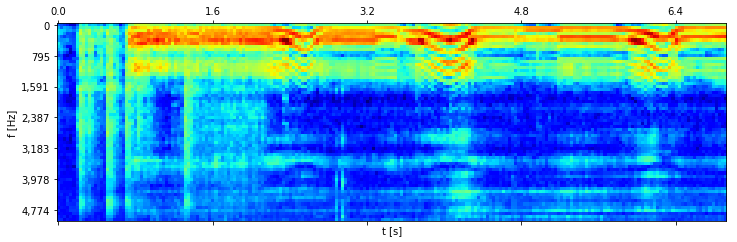

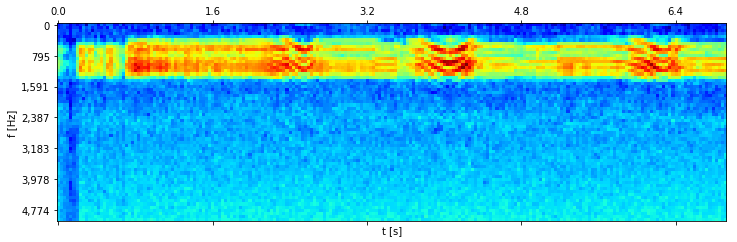

In [197]:
def butter_highpass(cutoff, order=5):
    nyq = 0.5 * settings.rate
    normal_cutoff = cutoff / nyq
    b, a = scipy.signal.butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_bandpass(lowcut, highcut, order=5):
    nyq = 0.5 * settings.rate
    low = lowcut / nyq
    high = highcut / nyq
    b, a = scipy.signal.butter(order, [low, high], btype='band', analog=False)
    return b, a

def bandpass_kaiser(ntaps, lowcut, highcut, fs, width):
    nyq = 0.5 * fs
    atten = kaiser_atten(ntaps, width / nyq)
    beta = kaiser_beta(atten)
    taps = firwin(ntaps, [lowcut, highcut], nyq=nyq, pass_zero=False,
                  window=('kaiser', beta), scale=False)
    return taps

h = scipy.signal.firwin(numtaps=100, cutoff=100, nyq=settings.rate/2)
b, a = butter_highpass(cutoff=800)
b, a = butter_bandpass(lowcut=400, highcut=800)
data = wav
data = util.int16_to_float(data)
# data = scipy.signal.lfilter(h, 1.0, data)
data = scipy.signal.filtfilt(b, a, data)
data = util.float_to_int16(data)

util.plot_logmel(features.log_mel_spectrogram(wav))
util.plot_logmel(features.log_mel_spectrogram(data))